<a href="https://colab.research.google.com/github/Ololade117/Inducing-Polysemanticity/blob/main/bias_mechanisms_notebook(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Six Custom Bias Mechanisms in a Character-Level Language Model

This notebook builds **one** architecture whose only difference across six versions
is *how the bias term works* inside each hidden layer. Everything else — embedding
table, weight matrices, the `tanh` nonlinearity, layer count, training loop,
optimizer, random seed — is identical, so any difference in behavior comes from the
bias mechanism alone.

**The six bias types**, all implemented inside `ManualLinear.forward` and picked
with a plain if/else based on a `bias_name` argument passed to the network:

| # | `bias_name` string | What `h = h @ W + b` becomes                                         |
|---|--------------------|-------------------------------------------------------------------------|
| 1 | `gated_sigmoid`    | `h@W + sigmoid(gate) * b` — a learned, sigmoid-squashed gate on `b`      |
| 2 | `gated_relu`       | `h@W + relu(gate) * b` — same idea, ReLU squashing instead               |
| 3 | `gated_tanh`       | `h@W + tanh(gate) * b` — same idea, tanh squashing instead               |
| 4 | `per_position`     | `h@W + b[position]` — a different fixed bias per context slot            |
| 5 | `flex`             | `h@W + (h @ v)` — a bias computed *from the input itself*, one value per row (the "flex bias") |
| 6 | `normal`           | `h@W + b` — the standard, single, fixed bias vector                      |

Every network is still a completely ordinary `nn.Module`: every weight, bias, gate
and flex-vector is a real `nn.Parameter`, held inside an `nn.ModuleList`. So
`model.parameters()`, `print(model)`, `model.state_dict()`, and
`model.layers[i].bias` all work exactly as they would for any built-in PyTorch
layer — the point of the whole exercise is to change the bias mechanism *without*
losing the ability to inspect the network normally.

**Task**: a small character-level name generator, trained on ~32k first names (the
dataset used in Andrej Karpathy's *makemore* series). Given a short window of
previous characters, predict the next one.

**Requirements**: a free [Hugging Face](https://huggingface.co) account with a
write-access token, to run the `push_to_hub` cells. Set `PUSH_TO_HUB = False` in
the setup cell if you just want to run everything else first.

**Notebook layout**
1. Setup
2. Data
3. Shared architecture (all six bias types defined once)
4. Inspecting the architecture *before* training anything
5. Shared training / evaluation / generation helpers
6–11. Six sections, one per bias type: build → train → inspect → push to Hugging Face
12. Side-by-side comparison of all six


## 0. Setup

In [1]:
# If a package is missing, uncomment and run:
# !pip install -q torch huggingface_hub matplotlib

import math
import random
import urllib.request

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from huggingface_hub import PyTorchModelHubMixin, notebook_login

torch.manual_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

HF_USERNAME = "Ololade117"   # <-- replace with your Hugging Face username
PUSH_TO_HUB = True                 # set False to skip the upload steps while testing

# Run this once, then paste a Hugging Face token with write access when prompted.
# notebook_login()


Using device: cuda


## 1. Data

The same 32k-name dataset used in *makemore*. Each name is wrapped with a
start/end token `.`, then cut into overlapping windows of `BLOCK_SIZE` characters
-> the character that follows.

e.g. with `BLOCK_SIZE = 3`, the name `"emma"` becomes:
`... -> e`, `..e -> m`, `.em -> m`, `emm -> a`, `mma -> .`


In [2]:
BLOCK_SIZE = 3  # how many previous characters the model conditions on

url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
words = urllib.request.urlopen(url).read().decode("utf-8").splitlines()
print(f"{len(words)} names, e.g. {words[:5]}")

chars = sorted(set("".join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi["."] = 0
itos = {i: ch for ch, i in stoi.items()}
VOCAB_SIZE = len(stoi)
print(f"vocab_size = {VOCAB_SIZE}: {itos}")


def build_dataset(words, block_size=BLOCK_SIZE):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)


random.seed(42)
shuffled = words[:]
random.shuffle(shuffled)
n1 = int(0.8 * len(shuffled))
n2 = int(0.9 * len(shuffled))

Xtr, Ytr = build_dataset(shuffled[:n1])
Xdev, Ydev = build_dataset(shuffled[n1:n2])
Xte, Yte = build_dataset(shuffled[n2:])
print("train/dev/test examples:", Xtr.shape[0], Xdev.shape[0], Xte.shape[0])


32033 names, e.g. ['emma', 'olivia', 'ava', 'isabella', 'sophia']
vocab_size = 27: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
train/dev/test examples: 182625 22655 22866


## 2. Shared architecture

`ManualLinear` is the one place `h = h @ W + b` lives. Every bias type is defined
here, chosen with an if/else on `bias_type`. `NormalBiasNet` stacks `ManualLinear`
layers and exposes a single `bias_name` argument that picks which bias mechanism
every hidden layer in that network uses (renamed from a plain `name` to avoid
colliding with `PyTorchModelHubMixin`'s own config/kwarg handling, which silently
swallowed a kwarg called `name` and always fell back to `"normal"`).

Inheriting from `PyTorchModelHubMixin` (in addition to `nn.Module`) is what gives
every model `.push_to_hub(...)`, `.save_pretrained(...)`, and `.from_pretrained(...)`
for free, later in this notebook.


In [3]:
class ManualLinear(nn.Module):
    """
    One h = h @ W + b step. `bias_type` selects which of the six bias
    mechanisms this layer uses -- every mechanism is defined right here.
    """

    def __init__(self, in_dim, out_dim, bias_type="normal", block_size=None):
        super().__init__()
        self.bias_type = bias_type
        self.weight = nn.Parameter(torch.randn(in_dim, out_dim) * in_dim ** -0.5)

        if bias_type == "normal":
            self.bias = nn.Parameter(torch.zeros(out_dim))

        elif bias_type in ("gated_sigmoid", "gated_relu", "gated_tanh"):
            self.bias = nn.Parameter(torch.zeros(out_dim))
            self.gate_param = nn.Parameter(torch.zeros(out_dim))  # learned, pre-activation

        elif bias_type == "per_position":
            assert block_size is not None, "per_position bias needs block_size"
            self.bias = nn.Parameter(torch.zeros(block_size, out_dim))

        elif bias_type == "flex":
            # maps h itself down to one scalar per row (per example, per position)
            self.flex_vec = nn.Parameter(torch.zeros(in_dim, 1))

        else:
            raise ValueError(f"Unknown bias_type: {bias_type!r}")

    def forward(self, h):
        out = h @ self.weight

        if self.bias_type == "normal":
            return out + self.bias

        elif self.bias_type == "gated_sigmoid":
            return out + torch.sigmoid(self.gate_param) * self.bias

        elif self.bias_type == "gated_relu":
            return out + torch.relu(self.gate_param) * self.bias

        elif self.bias_type == "gated_tanh":
            return out + torch.tanh(self.gate_param) * self.bias

        elif self.bias_type == "per_position":
            # self.bias: (block_size, out_dim) broadcasts over the batch dim
            return out + self.bias

        elif self.bias_type == "flex":
            flex_bias = h @ self.flex_vec  # (..., 1) -- one value per row
            return out + flex_bias

        else:
            raise ValueError(f"Unknown bias_type: {self.bias_type!r}")


class NormalBiasNet(
    nn.Module,
    PyTorchModelHubMixin,
    license="mit",
):
    """
    A standard nn.Module. `bias_name` picks the bias mechanism used by every hidden
    layer (see ManualLinear above) -- it's the only thing that changes between
    the six networks built later in this notebook.
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, block_size, n_layers=3, bias_name="normal"):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.block_size = block_size
        self.n_layers = n_layers
        self.bias_name = bias_name  # bias type used by every hidden layer in this model

        self.C = nn.Parameter(torch.randn(vocab_size, embed_dim))

        layers = []
        in_dim = embed_dim
        for _ in range(n_layers):
            layers.append(ManualLinear(in_dim, hidden_dim, bias_type=bias_name, block_size=block_size))
            in_dim = hidden_dim
        self.layers = nn.ModuleList(layers)

        # The output head always uses a plain bias: the six-way comparison is
        # about the *hidden* layers, so the head stays fixed across all of them.
        self.out = ManualLinear(hidden_dim * block_size, vocab_size, bias_type="normal")

    def forward(self, X):
        emb = self.C[X]                          # (batch, block_size, embed_dim)

        h = emb
        for layer in self.layers:
            h = torch.tanh(layer(h))              # (batch, block_size, hidden_dim)

        h = h.reshape(h.shape[0], -1)             # (batch, block_size * hidden_dim)
        logits = self.out(h)                      # raw logits -- loss fn applies softmax
        return logits


# Shared hyperparameters -- identical for all six models below, so the *only*
# thing that differs between them is the bias mechanism.
EMBED_DIM = 16
HIDDEN_DIM = 64
N_LAYERS = 3
STEPS = 4000
BATCH_SIZE = 128
LR = 3e-3


## 3. Inspecting the architecture, before training anything

This is the whole point of building it this way: even with a fully custom bias
mechanism, it's still an ordinary, inspectable `nn.Module`.


In [4]:
demo = NormalBiasNet(vocab_size=VOCAB_SIZE, embed_dim=8, hidden_dim=16,
                      block_size=BLOCK_SIZE, n_layers=2, bias_name="gated_sigmoid")
print(demo)

print("\nParameter shapes:")
for pname, p in demo.named_parameters():
    print(f"  {pname:20s} {tuple(p.shape)}")
print(f"\nTotal parameters: {sum(p.numel() for p in demo.parameters()):,}")

print("\nDirect access to one layer's pieces:")
print("  demo.layers[0].weight.shape ->", demo.layers[0].weight.shape)
print("  demo.layers[0].bias.shape   ->", demo.layers[0].bias.shape)
print("  demo.layers[0].gate_param   ->", demo.layers[0].gate_param)

# Sanity check: confirm the requested bias type actually made it into the
# layers. If this fails, `bias_name` isn't reaching ManualLinear and every
# model will silently train as "normal" regardless of what you asked for.
assert demo.bias_name == "gated_sigmoid", f"expected 'gated_sigmoid', got {demo.bias_name!r}"
assert demo.layers[0].bias_type == "gated_sigmoid", f"expected 'gated_sigmoid', got {demo.layers[0].bias_type!r}"
assert hasattr(demo.layers[0], "gate_param"), "gate_param missing -- this layer did not build as gated_sigmoid"
print("\nOK: bias_name correctly reached every layer's bias_type.")

del demo


NormalBiasNet(
  (layers): ModuleList(
    (0-1): 2 x ManualLinear()
  )
  (out): ManualLinear()
)

Parameter shapes:
  C                    (27, 8)
  layers.0.weight      (8, 16)
  layers.0.bias        (16,)
  layers.0.gate_param  (16,)
  layers.1.weight      (16, 16)
  layers.1.bias        (16,)
  layers.1.gate_param  (16,)
  out.weight           (48, 27)
  out.bias             (27,)

Total parameters: 1,987

Direct access to one layer's pieces:
  demo.layers[0].weight.shape -> torch.Size([8, 16])
  demo.layers[0].bias.shape   -> torch.Size([16])
  demo.layers[0].gate_param   -> Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       requires_grad=True)

OK: bias_name correctly reached every layer's bias_type.


## 4. Shared training / evaluation / generation helpers

Defined once and reused by all six sections below, so each section stays focused
on "build this one model, train it, look at it, push it" instead of repeating a
70-line training loop six times.


In [5]:
trained_models = {}
histories = {}


@torch.no_grad()
def split_loss(model, X, Y):
    model.eval()
    logits = model(X.to(DEVICE))
    loss = F.cross_entropy(logits, Y.to(DEVICE))
    model.train()
    return loss.item()


def train_model(model, steps=STEPS, batch_size=BATCH_SIZE, lr=LR, log_every=500):
    model.to(DEVICE)
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(steps // 3, 1), gamma=0.3)

    history = {"step": [], "train_loss": [], "dev_loss": []}
    for step in range(1, steps + 1):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        Xb, Yb = Xtr[ix].to(DEVICE), Ytr[ix].to(DEVICE)

        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        # manually-initialized nets can spike early; this keeps all six comparable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if step % log_every == 0 or step == 1:
            dev_loss = split_loss(model, Xdev, Ydev)
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["dev_loss"].append(dev_loss)
            print(f"step {step:5d} | train {loss.item():.3f} | dev {dev_loss:.3f}")

    return history


@torch.no_grad()
def generate(model, n=10, block_size=BLOCK_SIZE):
    model.eval()
    names = []
    for _ in range(n):
        context = [0] * block_size
        out = []
        while True:
            logits = model(torch.tensor([context]).to(DEVICE))
            probs = torch.softmax(logits, dim=-1)
            ix = torch.multinomial(probs, num_samples=1).item()
            if ix == 0:
                break
            out.append(itos[ix])
            context = context[1:] + [ix]
        names.append("".join(out))
    model.train()
    return names


def push(model, bias_type):
    repo_id = f"{HF_USERNAME}/bias-experiment-{bias_type.replace('_', '-')}"
    if PUSH_TO_HUB:
        model.push_to_hub(repo_id)
        print(f"Pushed to https://huggingface.co/{repo_id}")
    else:
        print(f"PUSH_TO_HUB is False -- skipping upload to {repo_id}")


## Section 1/6 — Gated Sigmoid Bias

The bias is scaled by a learned, per-unit `sigmoid(gate)` in (0, 1) -- the "how open is this gate" mechanism used in LSTMs, GRUs and GLU. `gate_param` starts at 0, so the gate starts half-open (`sigmoid(0) = 0.5`).

In [6]:
BIAS_TYPE = "gated_sigmoid"

torch.manual_seed(42)
model_gated_sigmoid = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_sigmoid.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_sigmoid.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_sigmoid)
print(f"parameters: {sum(p.numel() for p in model_gated_sigmoid.parameters()):,}")

history_gated_sigmoid = train_model(model_gated_sigmoid)

print("\nSample names:", generate(model_gated_sigmoid, n=10))

trained_models[BIAS_TYPE] = model_gated_sigmoid
histories[BIAS_TYPE] = history_gated_sigmoid


NormalBiasNet(
  (layers): ModuleList(
    (0-2): 3 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 15,243
step     1 | train 3.407 | dev 3.257
step   500 | train 2.051 | dev 2.356
step  1000 | train 2.289 | dev 2.359
step  1500 | train 2.433 | dev 2.311
step  2000 | train 2.272 | dev 2.306
step  2500 | train 2.305 | dev 2.305
step  3000 | train 2.175 | dev 2.292
step  3500 | train 2.330 | dev 2.290
step  4000 | train 2.294 | dev 2.288

Sample names: ['kritariky', 'juckon', 'dadar', 'ever', 'mairishaishaibellivi', 'betin', 'amurgemin', 'wysone', 'ion', 'maucirishon']


In [7]:
push(model_gated_sigmoid, "gated_sigmoid")


Pushed to https://huggingface.co/Ololade117/bias-experiment-gated-sigmoid


## Section 2/6 — Gated ReLU Bias

Same static-gate idea, but squashed with `relu` instead of `sigmoid`. Unlike sigmoid and tanh, this gate is **not bounded above** -- it starts fully closed (`relu(0) = 0`) but nothing stops it growing arbitrarily large during training. Watch the dev-loss curve for any instability this causes; gradient clipping is there to contain it.

In [8]:
BIAS_TYPE = "gated_relu"

torch.manual_seed(42)
model_gated_relu = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_relu.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_relu.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_relu)
print(f"parameters: {sum(p.numel() for p in model_gated_relu.parameters()):,}")

history_gated_relu = train_model(model_gated_relu)

print("\nSample names:", generate(model_gated_relu, n=10))

trained_models[BIAS_TYPE] = model_gated_relu
histories[BIAS_TYPE] = history_gated_relu


NormalBiasNet(
  (layers): ModuleList(
    (0-2): 3 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 15,243
step     1 | train 3.407 | dev 3.260
step   500 | train 2.051 | dev 2.357
step  1000 | train 2.291 | dev 2.358
step  1500 | train 2.431 | dev 2.312
step  2000 | train 2.275 | dev 2.306
step  2500 | train 2.302 | dev 2.305
step  3000 | train 2.177 | dev 2.293
step  3500 | train 2.328 | dev 2.290
step  4000 | train 2.294 | dev 2.288

Sample names: ['kritariky', 'juckon', 'dadar', 'ever', 'mairishaishaibellivi', 'beton', 'amurgemin', 'wysone', 'ion', 'maucirishon']


In [9]:
push(model_gated_relu, "gated_relu")


Pushed to https://huggingface.co/Ololade117/bias-experiment-gated-relu


## Section 3/6 — Gated Tanh Bias

Same static-gate idea again, squashed with `tanh` this time, so the gate can range over (-1, 1) -- meaning it can *subtract* the bias, not just scale it down. Starts fully closed (`tanh(0) = 0`).

In [10]:
BIAS_TYPE = "gated_tanh"

torch.manual_seed(42)
model_gated_tanh = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_gated_tanh.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_gated_tanh.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_gated_tanh)
print(f"parameters: {sum(p.numel() for p in model_gated_tanh.parameters()):,}")

history_gated_tanh = train_model(model_gated_tanh)

print("\nSample names:", generate(model_gated_tanh, n=10))

trained_models[BIAS_TYPE] = model_gated_tanh
histories[BIAS_TYPE] = history_gated_tanh


NormalBiasNet(
  (layers): ModuleList(
    (0-2): 3 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 15,243
step     1 | train 3.407 | dev 3.260
step   500 | train 2.051 | dev 2.357
step  1000 | train 2.291 | dev 2.358
step  1500 | train 2.431 | dev 2.312
step  2000 | train 2.275 | dev 2.306
step  2500 | train 2.302 | dev 2.305
step  3000 | train 2.177 | dev 2.293
step  3500 | train 2.328 | dev 2.290
step  4000 | train 2.294 | dev 2.288

Sample names: ['kritariky', 'juckon', 'dadar', 'ever', 'mairishaishaibellivi', 'beton', 'amurgemin', 'wysone', 'ion', 'maucirishon']


In [11]:
push(model_gated_tanh, "gated_tanh")


Pushed to https://huggingface.co/Ololade117/bias-experiment-gated-tanh


## Section 4/6 — Per-Position Bias

Instead of one bias vector shared by every position in the context window, each of the `BLOCK_SIZE` context slots gets its own learned bias -- closer to a positional embedding baked directly into the bias term.

In [12]:
BIAS_TYPE = "per_position"

torch.manual_seed(42)
model_per_position = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_per_position.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_per_position.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_per_position)
print(f"parameters: {sum(p.numel() for p in model_per_position.parameters()):,}")

history_per_position = train_model(model_per_position)

print("\nSample names:", generate(model_per_position, n=10))

trained_models[BIAS_TYPE] = model_per_position
histories[BIAS_TYPE] = history_per_position


NormalBiasNet(
  (layers): ModuleList(
    (0-2): 3 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 15,435
step     1 | train 3.407 | dev 3.249
step   500 | train 2.057 | dev 2.355
step  1000 | train 2.282 | dev 2.360
step  1500 | train 2.434 | dev 2.311
step  2000 | train 2.271 | dev 2.306
step  2500 | train 2.303 | dev 2.305
step  3000 | train 2.174 | dev 2.292
step  3500 | train 2.323 | dev 2.289
step  4000 | train 2.291 | dev 2.288

Sample names: ['kritariky', 'juckon', 'dadar', 'ever', 'mairishaishaibellive', 'beton', 'amurgemin', 'wysone', 'ion', 'maucirishon']


In [13]:
push(model_per_position, "per_position")


Pushed to https://huggingface.co/Ololade117/bias-experiment-per-position


## Section 5/6 — Flex Bias

Instead of a fixed, learned vector, the bias is *computed from the input itself*: `h @ v` maps each row of `h` down to a single scalar, so every example (and every position) gets its own bias value depending on its own content, rather than everyone sharing the same fixed vector.

In [14]:
BIAS_TYPE = "flex"

torch.manual_seed(42)
model_flex = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_flex.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_flex.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_flex)
print(f"parameters: {sum(p.numel() for p in model_flex.parameters()):,}")

history_flex = train_model(model_flex)

print("\nSample names:", generate(model_flex, n=10))

trained_models[BIAS_TYPE] = model_flex
histories[BIAS_TYPE] = history_flex


NormalBiasNet(
  (layers): ModuleList(
    (0-2): 3 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 15,003
step     1 | train 3.407 | dev 3.261
step   500 | train 2.054 | dev 2.360
step  1000 | train 2.300 | dev 2.360
step  1500 | train 2.425 | dev 2.311
step  2000 | train 2.266 | dev 2.306
step  2500 | train 2.300 | dev 2.304
step  3000 | train 2.170 | dev 2.292
step  3500 | train 2.328 | dev 2.290
step  4000 | train 2.295 | dev 2.288

Sample names: ['kritariky', 'juckon', 'dadar', 'ever', 'mairishaishaibellivi', 'betin', 'amurgemin', 'wysone', 'ion', 'maucirishon']


In [15]:
push(model_flex, "flex")


Pushed to https://huggingface.co/Ololade117/bias-experiment-flex


## Section 6/6 — Normal Bias

The baseline: one fixed, learned bias vector, identical for every input -- exactly what `nn.Linear` gives you for free. This is the control condition the other five are being compared against.

In [16]:
BIAS_TYPE = "normal"

torch.manual_seed(42)
model_normal = NormalBiasNet(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    block_size=BLOCK_SIZE, n_layers=N_LAYERS, bias_name=BIAS_TYPE,
)
assert model_normal.layers[0].bias_type == BIAS_TYPE, (
    f"expected {BIAS_TYPE!r}, got {model_normal.layers[0].bias_type!r} -- "
    "bias_name did not reach ManualLinear, stop and check this before training"
)
print(model_normal)
print(f"parameters: {sum(p.numel() for p in model_normal.parameters()):,}")

history_normal = train_model(model_normal)

print("\nSample names:", generate(model_normal, n=10))

trained_models[BIAS_TYPE] = model_normal
histories[BIAS_TYPE] = history_normal


NormalBiasNet(
  (layers): ModuleList(
    (0-2): 3 x ManualLinear()
  )
  (out): ManualLinear()
)
parameters: 15,051
step     1 | train 3.407 | dev 3.254
step   500 | train 2.050 | dev 2.355
step  1000 | train 2.291 | dev 2.361
step  1500 | train 2.437 | dev 2.311
step  2000 | train 2.273 | dev 2.306
step  2500 | train 2.306 | dev 2.304
step  3000 | train 2.175 | dev 2.292
step  3500 | train 2.328 | dev 2.289
step  4000 | train 2.293 | dev 2.288

Sample names: ['kritariky', 'juckon', 'dadar', 'ever', 'mairishaishaibellivi', 'betin', 'amurgemin', 'wysone', 'ion', 'maucirishon']


In [17]:
push(model_normal, "normal")


Pushed to https://huggingface.co/Ololade117/bias-experiment-normal


## 12. Comparing all six

All six models were trained identically -- same seed, same weight and embedding
initialization, same architecture sizes, same optimizer, same number of steps
(every bias parameter is zero-initialized, so it consumes none of the random
stream -- resetting the seed before each model gave all six the same `C` and
`weight` values). Any difference below comes only from how `b` in `h = h @ W + b`
worked.


bias type           params  final dev loss
gated_sigmoid       15,243           2.288
gated_relu          15,243           2.288
gated_tanh          15,243           2.288
per_position        15,435           2.288
flex                15,003           2.288
normal              15,051           2.288


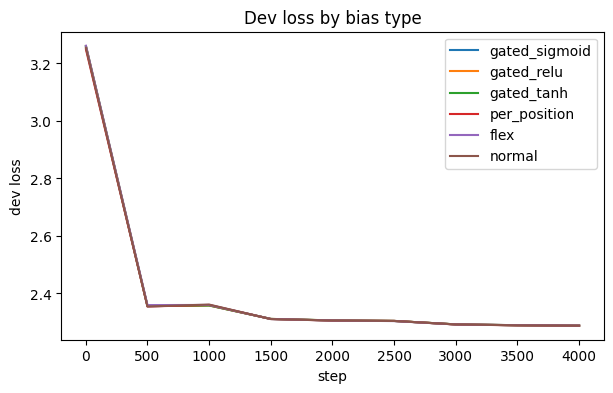


Sample names per model:
  gated_sigmoid  : ['insein', 'viestoni', 'krishay', 'kahcysh', 'trron']
  gated_relu     : ['mrien', 'crued', 'shedi', 'hamtry', 'kanyarrye']
  gated_tanh     : ['arey', 'joshke', 'tah', 'riza', 'rise']
  per_position   : ['gelenn', 'arelia', 'nakiriamarith', 'zikele', 'rilan']
  flex           : ['avinn', 'kaele', 'kalil', 'geelin', 'cka']
  normal         : ['cnas', 'shlwi', 'joh', 'jacqonn', 'safryth']


In [18]:
print(f"{'bias type':15s} {'params':>10s} {'final dev loss':>15s}")
for name, model in trained_models.items():
    n_params = sum(p.numel() for p in model.parameters())
    final_dev = histories[name]["dev_loss"][-1]
    print(f"{name:15s} {n_params:>10,d} {final_dev:>15.3f}")

plt.figure(figsize=(7, 4))
for name, h in histories.items():
    plt.plot(h["step"], h["dev_loss"], label=name)
plt.xlabel("step"); plt.ylabel("dev loss"); plt.legend(); plt.title("Dev loss by bias type")
plt.show()

print("\nSample names per model:")
for name, model in trained_models.items():
    print(f"  {name:15s}: {generate(model, n=5)}")


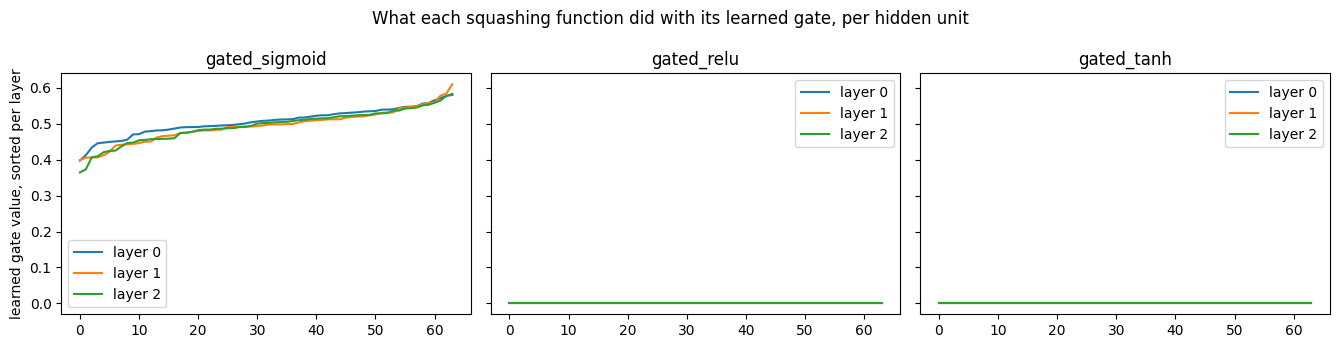

In [19]:
# What did the three gated variants actually learn to do with their gate?
gate_fns = {"gated_sigmoid": torch.sigmoid, "gated_relu": torch.relu, "gated_tanh": torch.tanh}
available = [n for n in gate_fns if n in trained_models]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(4.5 * len(available), 3.5), sharey=True)
    axes = [axes] if len(available) == 1 else axes
    for ax, name in zip(axes, available):
        model = trained_models[name]
        fn = gate_fns[name]
        for i, layer in enumerate(model.layers):
            gate_values = fn(layer.gate_param).detach().cpu().numpy()
            ax.plot(sorted(gate_values), label=f"layer {i}")
        ax.set_title(name)
        ax.legend()
    axes[0].set_ylabel("learned gate value, sorted per layer")
    plt.suptitle("What each squashing function did with its learned gate, per hidden unit")
    plt.tight_layout()
    plt.show()
else:
    print("No gated variants in trained_models -- run those sections first.")
